# Hierarchical Clustering

**INDE 577 / CMOR 438 — Rice University**  
**Instructor:** Randy R. Davila, PhD

---

## Overview

Hierarchical clustering builds a **tree of clusters** (dendrogram) either bottom-up (**agglomerative**) or top-down (**divisive**). It does not require specifying $k$ in advance — you can cut the tree at any level to get any number of clusters.

## Mathematical Background

### Agglomerative Clustering (Bottom-Up)

1. Start with each point as its own cluster
2. Repeatedly merge the two **closest** clusters
3. Stop when all points form a single cluster

### Linkage Criteria

**Single linkage** (minimum distance):
$$d(A, B) = \min_{\mathbf{a} \in A, \mathbf{b} \in B} d(\mathbf{a}, \mathbf{b})$$

**Complete linkage** (maximum distance):
$$d(A, B) = \max_{\mathbf{a} \in A, \mathbf{b} \in B} d(\mathbf{a}, \mathbf{b})$$

**Average linkage** (UPGMA):
$$d(A, B) = \frac{1}{|A| \cdot |B|} \sum_{\mathbf{a} \in A} \sum_{\mathbf{b} \in B} d(\mathbf{a}, \mathbf{b})$$

**Ward linkage** (minimize within-cluster variance):
$$d(A, B) = \sqrt{\frac{2|A||B|}{|A|+|B|}} \|\bar{\mathbf{a}} - \bar{\mathbf{b}}\|_2$$

### Dendrogram

The merging history is represented as a dendrogram. The **height** of each merge represents the distance at which the merge occurs. The number of clusters is determined by **cutting the dendrogram** at a threshold height.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import load_iris, make_blobs, make_moons
from sklearn.cluster import AgglomerativeClustering as SklearnAgglom
import warnings
warnings.filterwarnings('ignore')

from rice_ml import HierarchicalClustering
from rice_ml.processing.preprocessing import StandardScaler

print("Libraries loaded!")
np.random.seed(42)

Libraries loaded!


## 1. Dendrogram Visualization

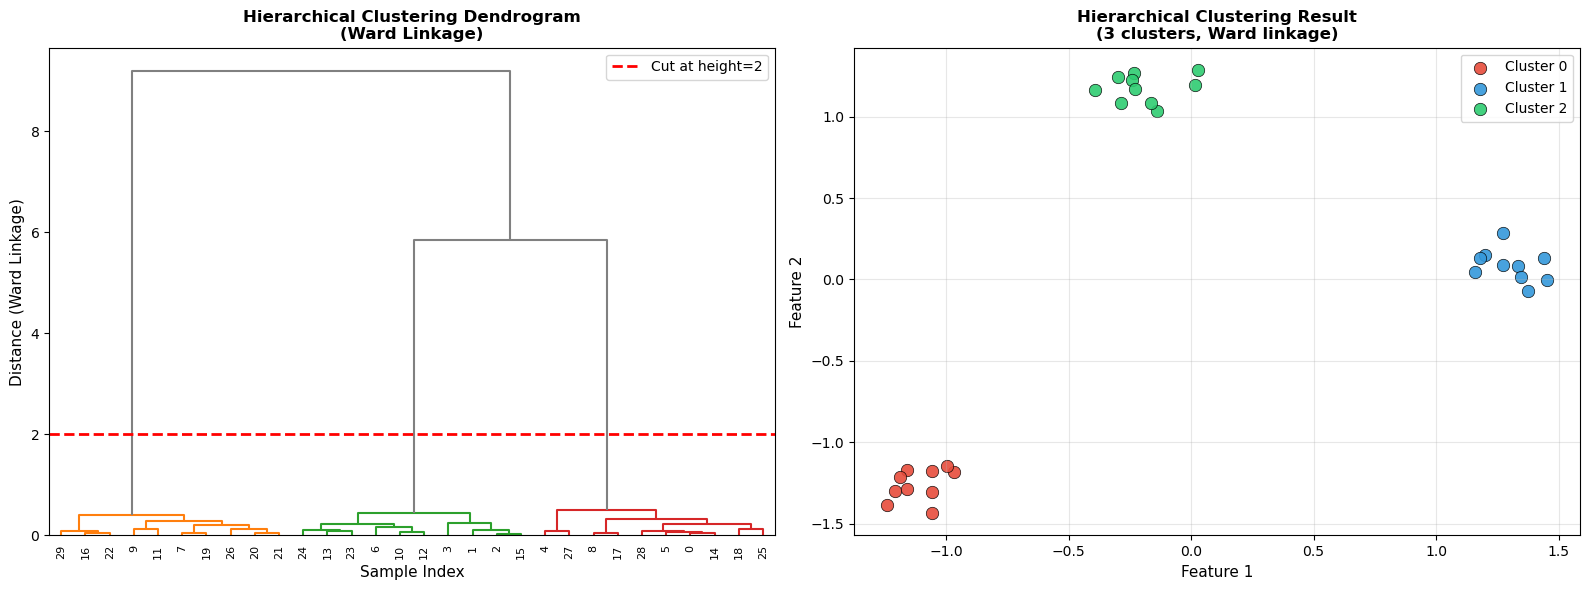

In [2]:
# Small dataset for dendrogram
np.random.seed(42)
X_small, _ = make_blobs(n_samples=30, centers=3, cluster_std=0.6, random_state=42)
scaler = StandardScaler()
X_small_s = scaler.fit_transform(X_small)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram using scipy (for visualization)
Z = linkage(X_small_s, method='ward')
ax = axes[0]
dn = dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=8,
                color_threshold=2.0, above_threshold_color='gray')
ax.axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Cut at height=2')
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('Distance (Ward Linkage)', fontsize=11)
ax.set_title('Hierarchical Clustering Dendrogram\n(Ward Linkage)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Cluster assignments from our implementation
hc = HierarchicalClustering(n_clusters=3, linkage='ward')
labels = hc.fit_predict(X_small_s)

ax2 = axes[1]
colors_3 = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(3):
    mask = labels == i
    ax2.scatter(X_small_s[mask, 0], X_small_s[mask, 1], c=colors_3[i], s=80,
                alpha=0.9, edgecolors='k', lw=0.5, label=f'Cluster {i}')
ax2.set_xlabel('Feature 1', fontsize=11)
ax2.set_ylabel('Feature 2', fontsize=11)
ax2.set_title('Hierarchical Clustering Result\n(3 clusters, Ward linkage)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Linkage Method Comparison

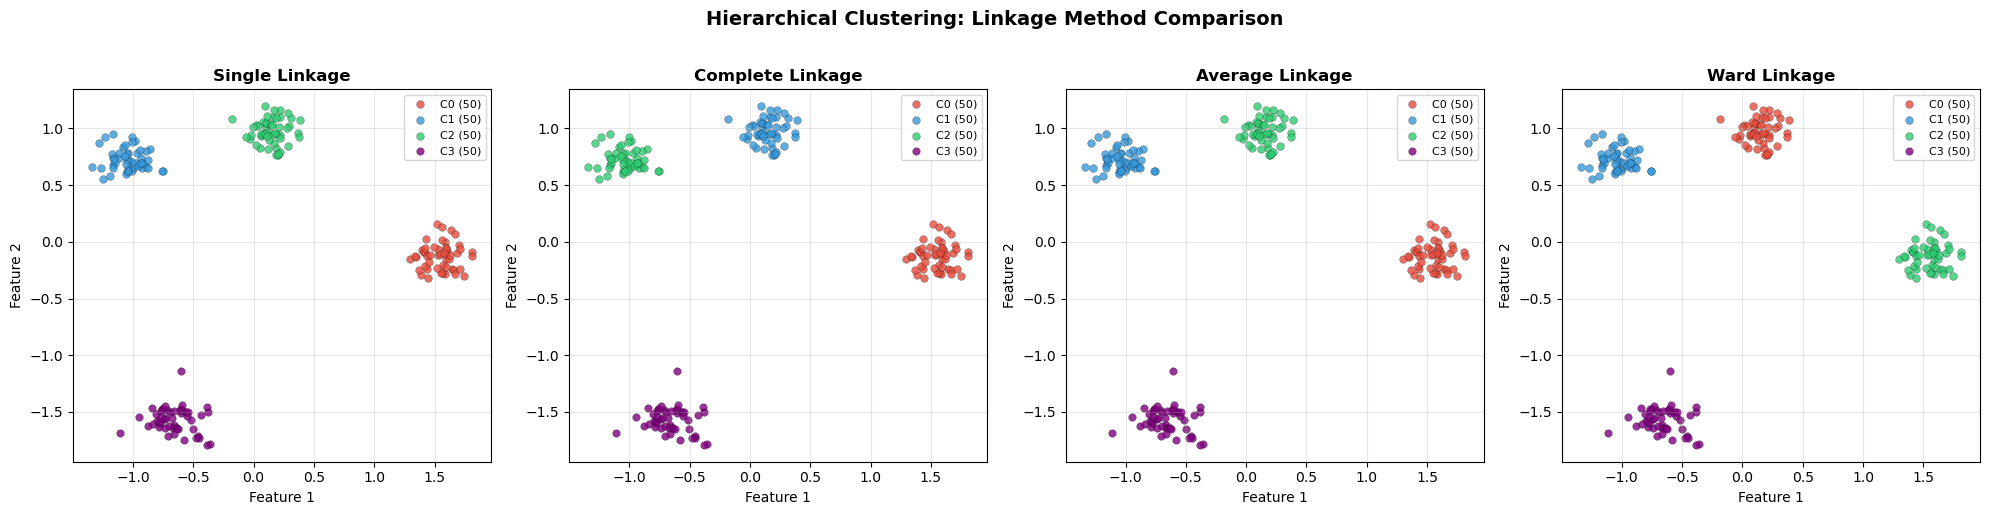

In [3]:
X_comp, _ = make_blobs(n_samples=200, centers=4, cluster_std=0.7, random_state=42)
scaler2 = StandardScaler()
X_comp_s = scaler2.fit_transform(X_comp)

linkage_methods = ['single', 'complete', 'average', 'ward']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, method in zip(axes, linkage_methods):
    hc_m = HierarchicalClustering(n_clusters=4, linkage=method)
    labels_m = hc_m.fit_predict(X_comp_s)
    
    # Compute cluster sizes
    sizes = [np.sum(labels_m == i) for i in range(4)]
    
    for i in range(4):
        mask = labels_m == i
        ax.scatter(X_comp_s[mask, 0], X_comp_s[mask, 1],
                   c=[colors_3[i % 3]] if i < 3 else ['purple'],
                   s=30, alpha=0.8, edgecolors='k', lw=0.2, label=f'C{i} ({sizes[i]})')
    
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=10)
    ax.set_ylabel('Feature 2', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Hierarchical Clustering: Linkage Method Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hierarchical_linkage.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Iris Dataset

Hierarchical Clustering vs True Labels (best mapping): 0.8267


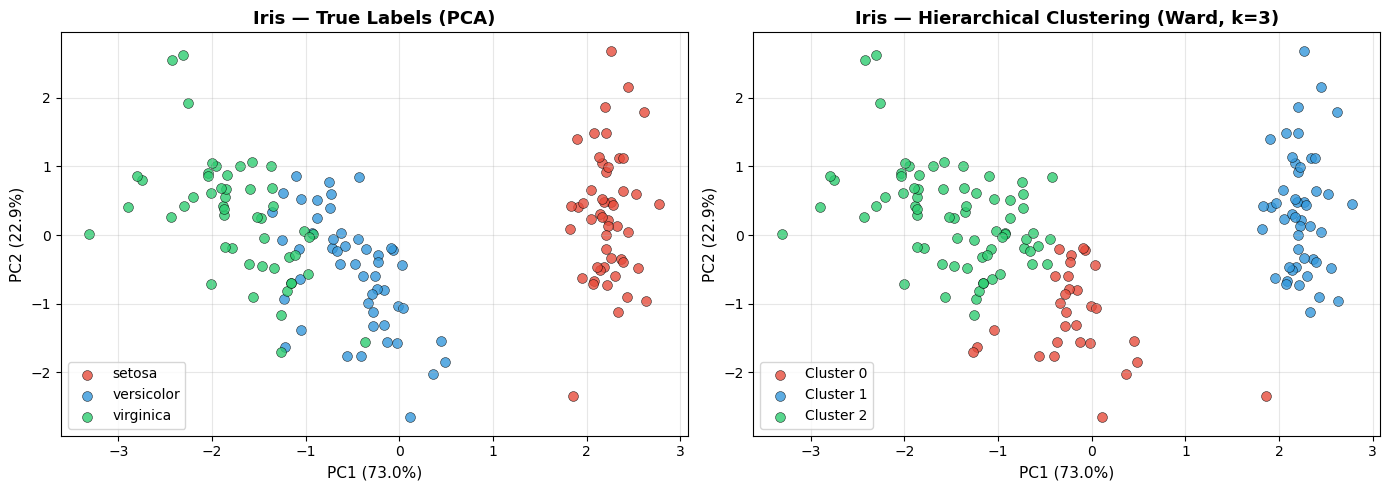

In [4]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
target_names = iris.target_names

scaler3 = StandardScaler()
X_iris_s = scaler3.fit_transform(X_iris)

hc_iris = HierarchicalClustering(n_clusters=3, linkage='ward')
labels_iris = hc_iris.fit_predict(X_iris_s)

# PCA for visualization
from rice_ml import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_iris = ['#e74c3c', '#3498db', '#2ecc71']

# True labels
ax = axes[0]
for i, (name, color) in enumerate(zip(target_names, colors_iris)):
    mask = y_iris == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=50, alpha=0.8,
               edgecolors='k', lw=0.4, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('Iris — True Labels (PCA)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Hierarchical clusters
ax2 = axes[1]
for i, color in enumerate(colors_iris):
    mask = labels_iris == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, s=50, alpha=0.8,
                edgecolors='k', lw=0.4, label=f'Cluster {i}')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax2.set_title('Iris — Hierarchical Clustering (Ward, k=3)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Compute agreement
from collections import Counter
# Best label mapping (Hungarian-style simple version)
best_acc = 0
from itertools import permutations
for perm in permutations([0, 1, 2]):
    mapped = np.array([perm[l] for l in labels_iris])
    acc_p = np.mean(mapped == y_iris)
    if acc_p > best_acc:
        best_acc = acc_p

print(f"Hierarchical Clustering vs True Labels (best mapping): {best_acc:.4f}")

plt.tight_layout()
plt.savefig('hierarchical_iris.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Single Linkage — Chaining Effect

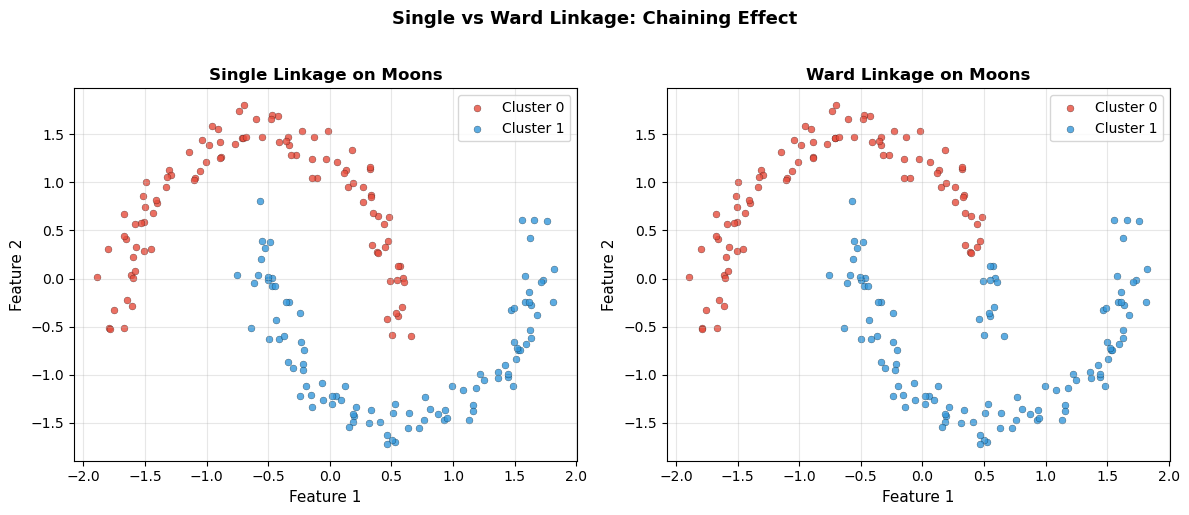

Single linkage follows the 'chain' shape (good for elongated clusters)
Ward linkage creates more compact, spherical clusters


In [5]:
X_moons, _ = make_moons(n_samples=200, noise=0.07, random_state=42)
scaler4 = StandardScaler()
X_moons_s = scaler4.fit_transform(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, method in zip(axes, ['single', 'ward']):
    hc_m = HierarchicalClustering(n_clusters=2, linkage=method)
    labels_m = hc_m.fit_predict(X_moons_s)
    
    for i, color in enumerate(['#e74c3c', '#3498db']):
        mask = labels_m == i
        ax.scatter(X_moons_s[mask, 0], X_moons_s[mask, 1], c=color, s=25,
                   alpha=0.8, edgecolors='k', lw=0.2, label=f'Cluster {i}')
    
    ax.set_title(f'{method.capitalize()} Linkage on Moons', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Single vs Ward Linkage: Chaining Effect', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hierarchical_chaining.png', dpi=120, bbox_inches='tight')
plt.show()
print("Single linkage follows the 'chain' shape (good for elongated clusters)")
print("Ward linkage creates more compact, spherical clusters")

## Summary

| Linkage | Cluster Shape | Sensitivity | Notes |
|---|---|---|---|
| Single | Elongated/chain | Outliers | Chaining effect |
| Complete | Compact | Outliers | Tends to equal-size clusters |
| Average | Moderate | Moderate | Balance between single & complete |
| Ward | Compact, spherical | Robust | Minimizes within-cluster variance |

**Key Takeaways:**
- Hierarchical clustering provides a **full hierarchy** — no need to commit to a fixed $k$
- The **dendrogram** is a powerful visualization tool for understanding cluster structure
- **Ward linkage** generally performs best for compact, well-separated clusters
- **Single linkage** follows elongated shapes but is sensitive to chaining
- $O(n^2)$ memory and $O(n^3)$ time makes it slow for large datasets